In [90]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [268]:
df=pd.read_csv('laptop_price.csv',encoding='latin1')
df.head(4)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45


In [269]:
df.shape

(1303, 13)

In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [271]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [272]:
df.duplicated().sum()

np.int64(0)

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


### PREPROCESS

In [274]:
df=df.drop(columns='laptop_ID')
df.head(3)

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00


In [275]:
df['Ram']=df['Ram'].str.replace('GB','')
df['Weight']=df['Weight'].str.replace('kg','')
df.head(2)

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94


In [276]:
df['Ram']=df['Ram'].astype('int32')
df['Weight']=df['Weight'].astype('float32')

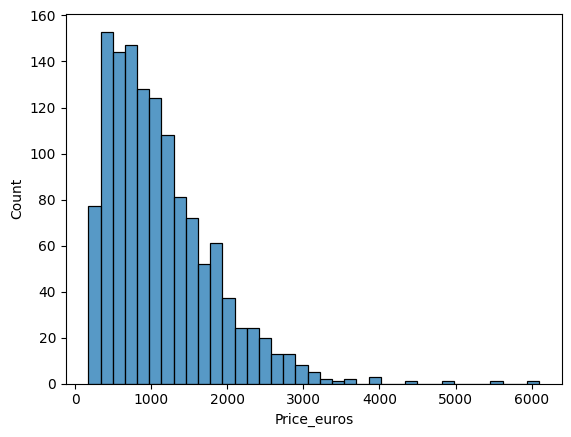

In [277]:
sns.histplot(df['Price_euros'])
plt.show()

In [278]:
# data is right skewed

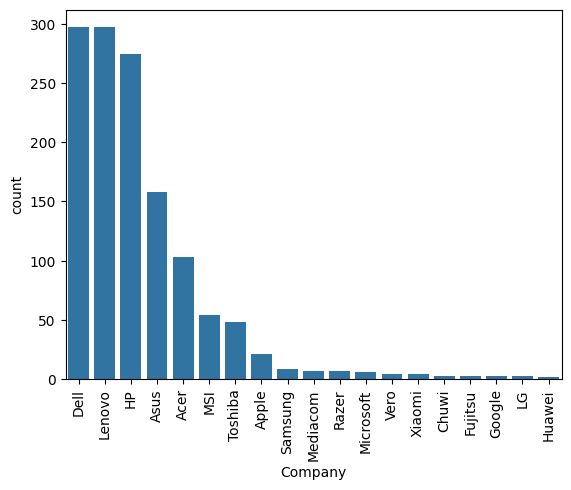

In [279]:
sns.barplot(df['Company'].value_counts())
plt.xticks(rotation=90)
plt.show()

In [280]:
# we can remove the less sold laptops

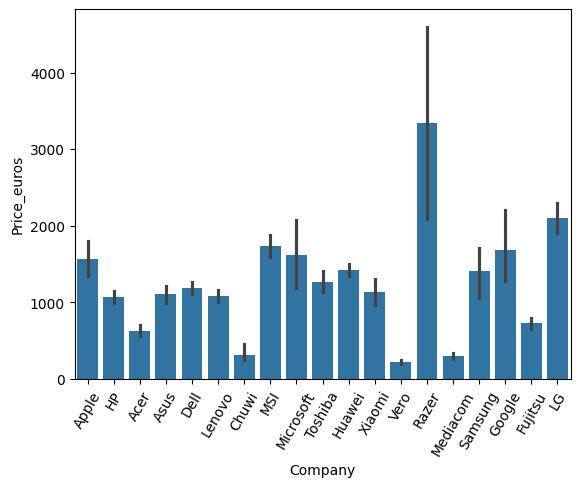

In [281]:
sns.barplot(x='Company',y='Price_euros',data=df)
plt.xticks(rotation=60)
plt.show()

In [282]:
df=df.drop(columns='Product')

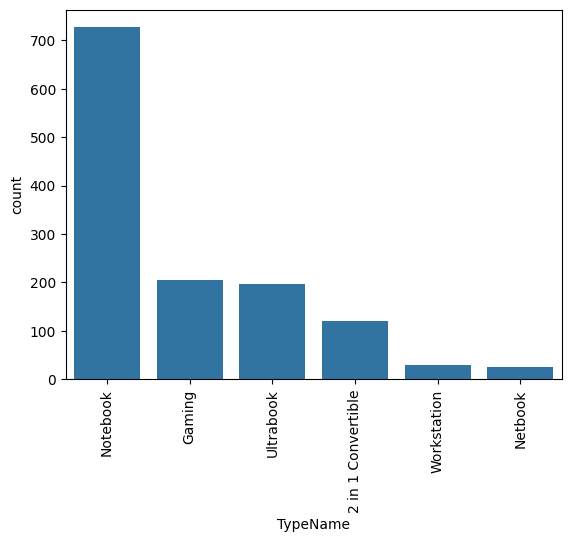

In [283]:
sns.barplot(df['TypeName'].value_counts())
plt.xticks(rotation=90)
plt.show()

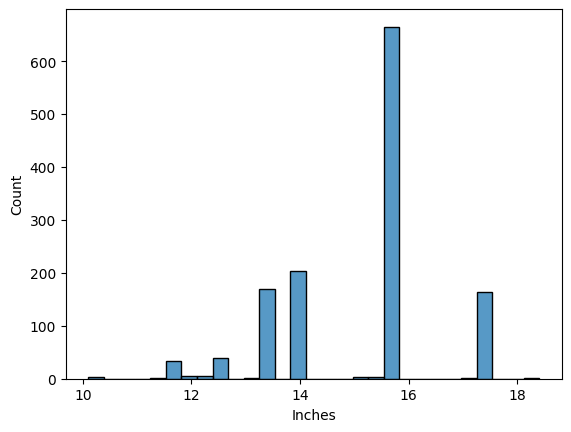

In [284]:
sns.histplot(df['Inches'])
plt.show()

<Axes: xlabel='Inches', ylabel='Price_euros'>

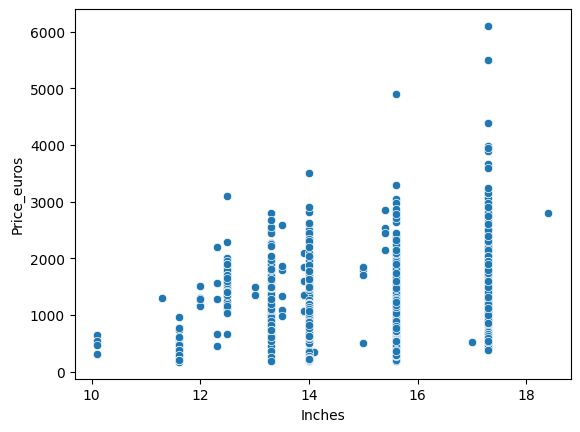

In [285]:
sns.scatterplot(x=df['Inches'],y=df['Price_euros'])

In [286]:
# a slight direct relation

In [287]:
df.head(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00


In [288]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [289]:
df['Touchscreen']=df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

In [290]:
df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

<Axes: xlabel='Touchscreen', ylabel='Price_euros'>

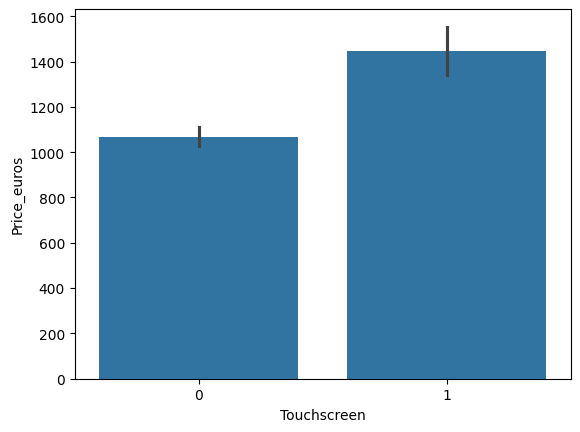

In [291]:
sns.barplot(x='Touchscreen',y='Price_euros',data=df)

In [292]:
df['IPS']=df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

In [293]:
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

<Axes: xlabel='IPS', ylabel='Price_euros'>

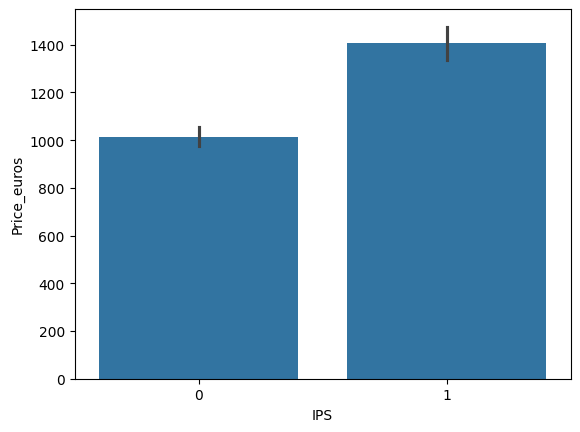

In [294]:
sns.barplot(x='IPS',y='Price_euros',data=df)

In [295]:
df[['XResolution','YResolution']]=df["ScreenResolution"].str.lower().str.split('x',n=1,expand=True)

In [296]:
df['XResolution']

0               ips panel retina display 2560
1                                        1440
2                                full hd 1920
3               ips panel retina display 2880
4               ips panel retina display 2560
                        ...                  
1298     ips panel full hd / touchscreen 1920
1299    ips panel quad hd+ / touchscreen 3200
1300                                     1366
1301                                     1366
1302                                     1366
Name: XResolution, Length: 1303, dtype: object

In [297]:
df['XResolution']=df['XResolution'].str.extract(r'(\d+)$')
df['XResolution'].unique()

array(['2560', '1440', '1920', '2880', '1366', '2304', '3200', '2256',
       '3840', '2160', '1600', '2736', '2400'], dtype=object)

<Axes: xlabel='ScreenResolution', ylabel='Price_euros'>

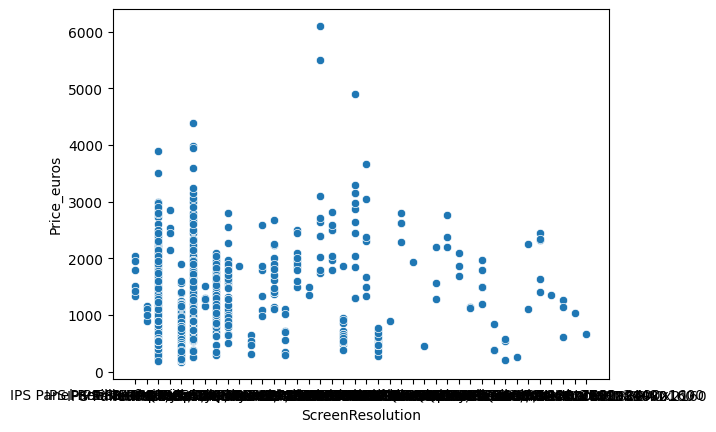

In [298]:
sns.scatterplot(x='ScreenResolution',y='Price_euros',data=df)

In [299]:
df['XResolution']=df['XResolution'].astype('int')
df['YResolution']=df['YResolution'].astype('int')

In [300]:
df.corr(numeric_only=True)['Price_euros']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price_euros    1.000000
Touchscreen    0.191226
IPS            0.252208
XResolution    0.556529
YResolution    0.552809
Name: Price_euros, dtype: float64

In [301]:
df['PPI']=((df['XResolution'])**2+(df['XResolution'])**2)**0.5/(df['Inches']).astype('float')

In [302]:
df.corr(numeric_only=True)['Price_euros']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price_euros    1.000000
Touchscreen    0.191226
IPS            0.252208
XResolution    0.556529
YResolution    0.552809
PPI            0.474973
Name: Price_euros, dtype: float64

In [303]:
df=df.drop(columns=['XResolution','YResolution','Inches','ScreenResolution'])

In [304]:
df.head(3)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,272.209528
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,153.117859
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0,174.057054


In [305]:
df['Cpu name']=df['Cpu'].apply(lambda x: ' '.join(x.split(' ')[0:3]))
df['Cpu name'].value_counts()

Cpu name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
AMD A8-Series 7410            4
Intel Atom x5-Z8550           4
AMD A9-Series 9410            3
Intel Pentium Dual            3
AMD Ryzen 1700                3
AMD A9-Series A9-9420         2
AMD E-Series E2-9000e         2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD E-Series 7110             2
AMD A10-Series 9620P          2
AMD A10-Series 9600P          2
Intel Xeon E3-1505M           2
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
Intel Atom x5-Z8300           1
AMD E-Series 6110             1
AMD E-Series 9000e            1
AMD E-Series E2-6110          1
AMD FX 9830P                  1

In [306]:
def process_cpu(value):
    if value=='Intel Core i5' or value=='Intel Core i7' or value=='Intel Core i3':
        return value
    else:
        if value.split(' ')[0]=='Intel':
            return 'Other Intel Processors'
        else:
            return 'AMD processors'

In [307]:
df['Processor']=df['Cpu name'].apply(process_cpu)
df['Processor'].value_counts()

Processor
Intel Core i7             527
Intel Core i5             423
Other Intel Processors    154
Intel Core i3             136
AMD processors             63
Name: count, dtype: int64

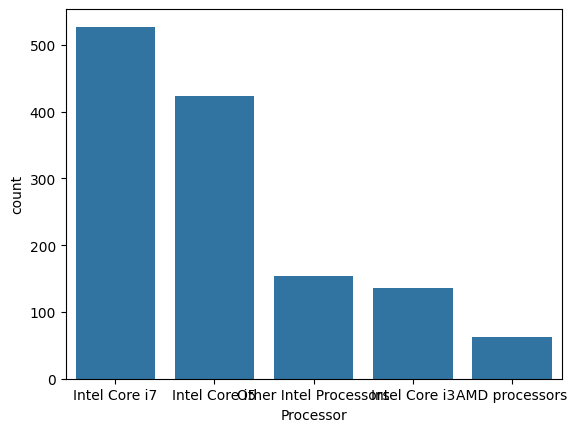

In [308]:
sns.barplot(df['Processor'].value_counts())
plt.show()

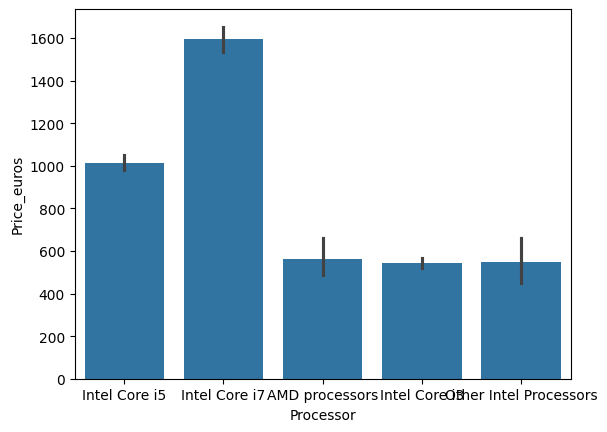

In [309]:
sns.barplot(x=df['Processor'],y=df['Price_euros'])
plt.show()

In [310]:
df['Cpu'].unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Atom x5-Z8350 1.44GHz',
       'Intel Core i5 7300HQ 2.5GHz', 'AMD E-Series E2-9000e 1.5GHz',
       'Intel Core i5 1.6GHz', 'Intel Core i7 8650U 1.9GHz',
       'Intel Atom x5-Z8300 1.44GHz', 'AMD E-Series E2-6110 1.5GHz',
       'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Atom x5-Z8550 1.44GHz',
       'Intel Celeron Du

In [314]:
df['processor speed']=df['Cpu'].str.split(' ').str[-1]
df['processor speed']=df['processor speed'].str.extract(r'(\d+\.\d+)')
df['processor speed']=df['processor speed'].astype('float')
df['processor speed']=df['processor speed'].fillna(df['processor speed'].median())

In [315]:
df.corr(numeric_only=True)['Price_euros']

Ram                0.743007
Weight             0.210370
Price_euros        1.000000
Touchscreen        0.191226
IPS                0.252208
PPI                0.474973
processor speed    0.396029
Name: Price_euros, dtype: float64

In [316]:
df=df.drop(columns=['Cpu','Cpu name'])

In [317]:
df.head(4)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI,Processor,processor speed
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,272.209528,Intel Core i5,2.3
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,153.117859,Intel Core i5,1.8
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0,174.057054,Intel Core i5,2.5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,264.476303,Intel Core i7,2.7


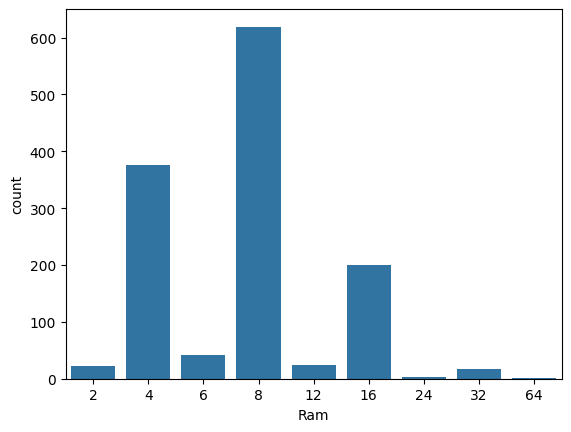

In [318]:
sns.barplot(df['Ram'].value_counts())
plt.show()

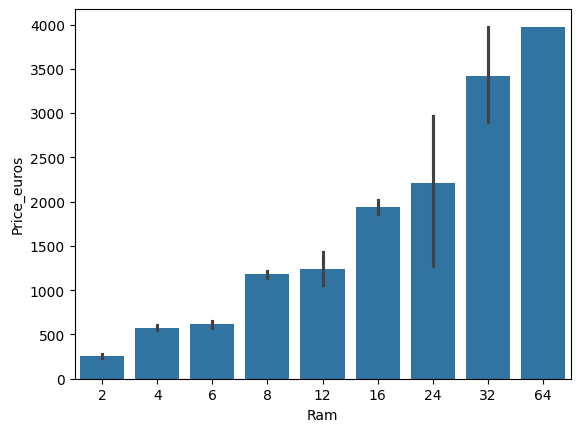

In [319]:
sns.barplot(x=df['Ram'],y=df['Price_euros'])
plt.show()

In [320]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [321]:
import pandas as pd

# 1. Basic cleaning: remove '.0', 'GB', and replace 'TB' with '000' to standardize units
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df['Memory'] = df['Memory'].str.replace('GB', '')
df['Memory'] = df['Memory'].str.replace('TB', '000')

# 2. Split by the '+' sign for dual drives
new = df['Memory'].str.split("+", n=1, expand=True)

df['first'] = new[0].str.strip()
df['second'] = new[1].str.strip()

# 3. Create flags for storage types
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1Flash"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)

# 4. Extract numbers from the first part
df['first'] = df['first'].str.extract('(\d+)')

# 5. Repeat for the second drive (handling the 'None' values)
df["second"].fillna("0", inplace=True)

df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2Flash"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)

# 6. Extract numbers from the second part
df['second'] = df['second'].str.extract('(\d+)')

# 7. Convert to integers and multiply by flags to get final capacities
df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

df["SSD"] = (df["first"] * df["Layer1SSD"] + df["second"] * df["Layer2SSD"])
df["HDD"] = (df["first"] * df["Layer1HDD"] + df["second"] * df["Layer2HDD"])
df["Flash_Storage"] = (df["first"] * df["Layer1Flash"] + df["second"] * df["Layer2Flash"])
df["Hybrid"] = (df["first"] * df["Layer1Hybrid"] + df["second"] * df["Layer2Hybrid"])

# 8. Drop temporary helper columns
df.drop(columns=['first', 'second', 'Layer1SSD', 'Layer1HDD', 'Layer1Flash', 
                 'Layer1Hybrid', 'Layer2SSD', 'Layer2HDD', 'Layer2Flash', 'Layer2Hybrid'], inplace=True)


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3580\3444136924.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3580\3444136924.py:21: SyntaxWarning: invalid escape sequence '\d'
  df['first'] = df['first'].str.extract('(\d+)')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3580\3444136924.py:32: SyntaxWarning: invalid escape sequence '\d'
  df['second'] = df['second'].str.extract('(\d+)')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3580\3444136924.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplac

In [322]:
df.head(3)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI,Processor,processor speed,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,272.209528,Intel Core i5,2.3,128,0,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,153.117859,Intel Core i5,1.8,0,0,128,0
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0,174.057054,Intel Core i5,2.5,256,0,0,0


In [323]:
df=df.drop(columns="Memory")

In [324]:
df.corr(numeric_only=True)['Price_euros']

Ram                0.743007
Weight             0.210370
Price_euros        1.000000
Touchscreen        0.191226
IPS                0.252208
PPI                0.474973
processor speed    0.396029
SSD                0.670799
HDD               -0.096441
Flash_Storage     -0.040511
Hybrid             0.007989
Name: Price_euros, dtype: float64

In [325]:
df=df.drop(columns=["Flash_Storage",'Hybrid'])

In [326]:
df.head(3)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI,Processor,processor speed,SSD,HDD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,272.209528,Intel Core i5,2.3,128,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,153.117859,Intel Core i5,1.8,0,0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,575.00,0,0,174.057054,Intel Core i5,2.5,256,0


In [327]:
df['Gpu'].unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce 940MX', 'Intel HD Graphics 400',
       'Nvidia GeForce GTX 1050', 'AMD Radeon R2', 'AMD Radeon 530',
       'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce 930MX ',
       'Nvidia GeForce GTX 1060', 'Nvidia GeForce 150MX',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvid

In [328]:
df['Gpu Brand']=df['Gpu'].apply(lambda x: x.split(' ')[0])
df['Gpu Brand'].value_counts()

Gpu Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [329]:
df=df[df['Gpu Brand']!='ARM']
df['Gpu Brand'].value_counts()

Gpu Brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

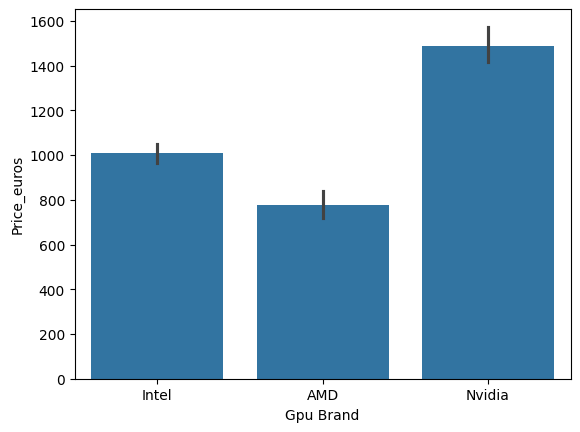

In [330]:
sns.barplot(x=df['Gpu Brand'],y=df['Price_euros'])
plt.show()

In [331]:
df=df.drop(columns='Gpu')

In [332]:
df.head(2)

,Company,TypeName,Ram,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI,Processor,processor speed,SSD,HDD,Gpu Brand
0,Apple,Ultrabook,8,macOS,1.37,1339.69,0,1,272.209528,Intel Core i5,2.3,128,0,Intel
1,Apple,Ultrabook,8,macOS,1.34,898.94,0,0,153.117859,Intel Core i5,1.8,0,0,Intel


In [333]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [334]:
def process_os(value):
    if value in ['Windows 10','Windows 7','Windows 10 S']:
        return 'Windows'
    elif value in ['Mac OS X','macOS']:
        return 'Mac'
    else:
        return 'Others\Android\Chrome'

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3580\3561128331.py:7: SyntaxWarning: invalid escape sequence '\A'
  return 'Others\Android\Chrome'


In [335]:
df['OS']=df['OpSys'].apply(process_os)

In [336]:
df=df.drop(columns='OpSys')

<Axes: xlabel='OS', ylabel='Price_euros'>

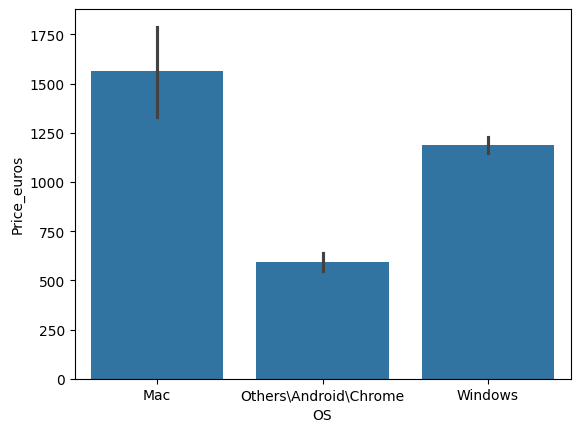

In [337]:
sns.barplot(x=df['OS'],y=df['Price_euros'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3580\3623460905.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'],kde=True)


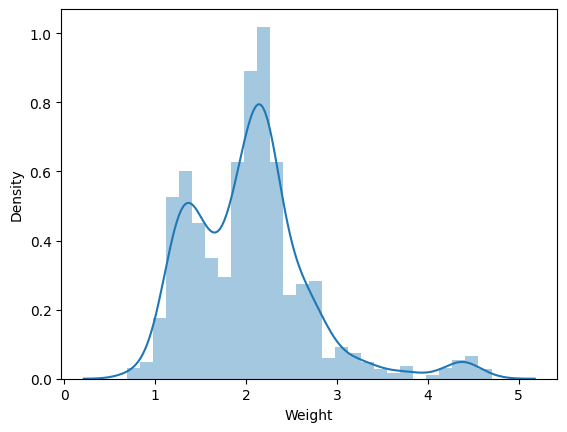

In [338]:
sns.distplot(df['Weight'],kde=True)
plt.show()

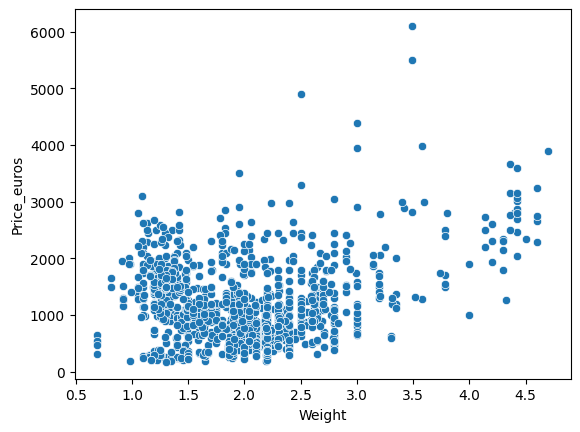

In [339]:
sns.scatterplot(x=df['Weight'],y=df['Price_euros'])
plt.show()

In [340]:
df.corr(numeric_only=True)['Price_euros']

Ram                0.742905
Weight             0.209867
Price_euros        1.000000
Touchscreen        0.192917
IPS                0.253320
PPI                0.476578
processor speed    0.395832
SSD                0.670660
HDD               -0.096891
Name: Price_euros, dtype: float64

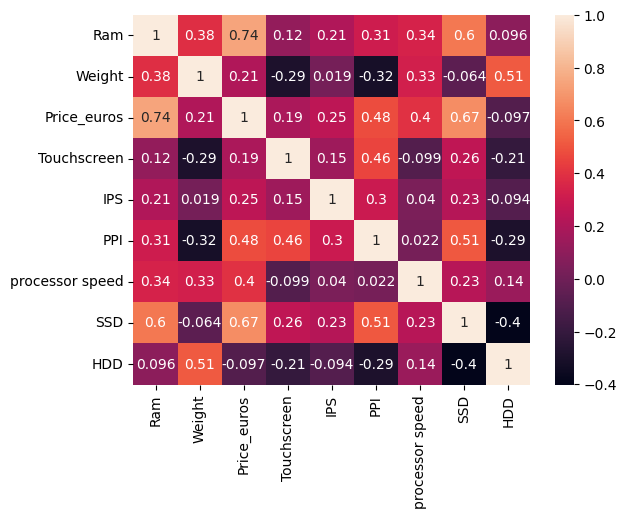

In [341]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

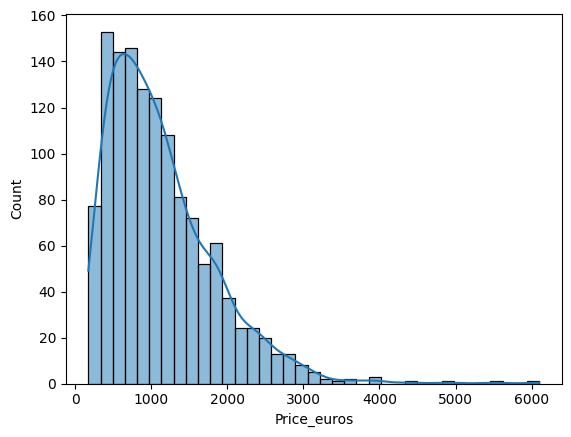

In [342]:
sns.histplot(df['Price_euros'],kde=True)
plt.show()  

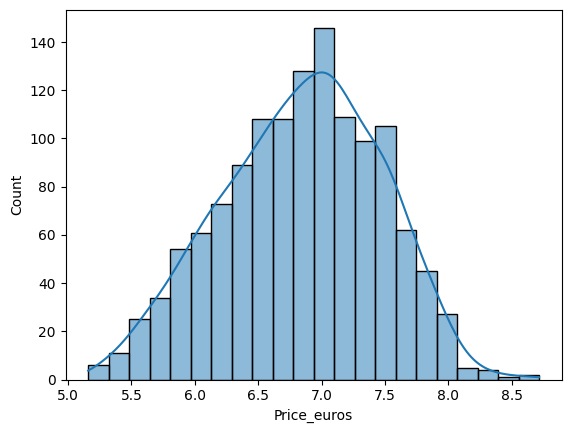

In [343]:
sns.histplot(np.log(df['Price_euros']),kde=True)
plt.show()

In [344]:
df['Price']=np.log(df['Price_euros'])
df=df.drop(columns='Price_euros')

In [345]:
df.head(3)

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Processor,processor speed,SSD,HDD,Gpu Brand,OS,Price
0,Apple,Ultrabook,8,1.37,0,1,272.209528,Intel Core i5,2.3,128,0,Intel,Mac,7.200194
1,Apple,Ultrabook,8,1.34,0,0,153.117859,Intel Core i5,1.8,0,0,Intel,Mac,6.801216
2,HP,Notebook,8,1.86,0,0,174.057054,Intel Core i5,2.5,256,0,Intel,Others\Android\Chrome,6.354370


In [377]:
X=df.drop(columns='Price')
Y=df['Price']
X.isnull().sum()

Company            0
TypeName           0
Ram                0
Weight             0
Touchscreen        0
IPS                0
PPI                0
Processor          0
processor speed    0
SSD                0
HDD                0
Gpu Brand          0
OS                 0
dtype: int64

In [378]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [388]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
preprocessor=ColumnTransformer([
    ('encode',OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False),[0,1,7,11,12]),
    ('scale',StandardScaler(),['Ram','Weight','PPI','processor speed','SSD','HDD'])
])

### Linear Regression

In [389]:
import warnings
warnings.filterwarnings('ignore')

In [390]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',LinearRegression())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

0.8196538257902478
0.20938682372631495


### Ridge Regression

In [394]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',Ridge())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print('Before Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

param_grid={
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0], 
    'model__solver': ['auto', 'cholesky', 'saga']
}
grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='r2',
    error_score='raise'
)
grid.fit(x_train,y_train)
y_predict=grid.predict(x_test)

print('After Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(' ')
print(grid.best_score_)

Before Tuning
0.8191565019255068
0.20918342045607108
After Tuning
0.8191157972505202
0.20919427252795683
 
0.8166559469817691


### KNN

In [395]:
from sklearn.neighbors import KNeighborsRegressor
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',KNeighborsRegressor())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print('Before Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

param_grid={
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}
grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='r2'
)
grid.fit(x_train,y_train)
y_predict=grid.predict(x_test)

print('After Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(' ')
print(grid.best_score_)

Before Tuning
0.8447359844175046
0.18570548157215197
After Tuning
0.8704633638806503
0.16819380904337844
 
0.8573237859634494


### SVM

In [396]:
from sklearn.svm import SVR
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',SVR())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print('Before Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

param_grid={
   'model__kernel': ['rbf', 'linear'],
    'model__C': [0.1, 1, 10,100],
    'model__epsilon': [0.01, 0.1, 0.2]
}
grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='r2'
)
grid.fit(x_train,y_train)
y_predict=grid.predict(x_test)

print('After Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(' ')
print(grid.best_score_)

Before Tuning
0.875609361543432
0.16996346770990337
After Tuning
0.875609361543432
0.16996346770990337
 
0.8671016690357243


### Decision Tree

In [397]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',DecisionTreeRegressor())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print('Before Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

param_grid={
  'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__max_features': ['sqrt', 'log2', None],
}
grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='r2'
)
grid.fit(x_train,y_train)
y_predict=grid.predict(x_test)

print('After Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(' ')
print(grid.best_score_)

Before Tuning
0.8585422237604394
0.17361154716110216
After Tuning
0.8406860689963267
0.186951827171686
 
0.8042554281125907


### Random Forest

In [399]:
from sklearn.ensemble import RandomForestRegressor
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',RandomForestRegressor())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print('Before Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

param_grid={
  'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 15, 25],
    'model__max_samples': [0.5, 0.75, 1.0]
}
grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='r2'
)
grid.fit(x_train,y_train)
y_predict=grid.predict(x_test)

print('After Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(' ')
print(grid.best_score_)

Before Tuning
0.8950814838679275
0.15346220785931175
After Tuning
0.8891196336343791
0.15818332794903403
 
0.8676718898755659


### Xgboost

In [401]:
from xgboost import XGBRegressor
pipeline=Pipeline([
    ('prep',preprocessor),
    ('model',XGBRegressor())
])
pipeline.fit(x_train,y_train)
y_predict=pipeline.predict(x_test)

print('Before Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))

param_grid={
  'model__n_estimators': [100, 500],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}
grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='r2'
)
grid.fit(x_train,y_train)
y_predict=grid.predict(x_test)

print('After Tuning')
print(r2_score(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(' ')
print(grid.best_score_)

Before Tuning
0.898121938585289
0.14751173822556113
After Tuning
0.894026791725852
0.15150536265781936
 
0.8886746172771349


In [404]:
import pickle
model=grid
pickle.dump(model,open('model.pkl','wb'))
pickle.dump(df,open('df.pkl','wb'))
